# 9. Natural orbitals

"Natural orbitals" are the eigenstates of the one-body reduced density matrix. If the corresponding quantum state is a Slater determinant, the density matrix will have eigenvalues $0$ and $1$, and the eigenstates with eigenvalue $1$ form the Slater determinant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fermi_relations as fr

In [2]:
# random number generator
rng = np.random.default_rng(50)

In [3]:
# number of modes
nmodes = 7

# number of particles
nptcl = 4

# create a random Slater determinant
psi = fr.SlaterDeterminant.random(nmodes, nptcl, orthonormal=True, rng=rng)

We first compute the one-body reduced density matrix $\rho$:

In [4]:
# compute the one-body reduced density matrix of 'psi' using its Slater determinant form
rho = fr.rdm1_slater_sum([psi])

# compare with reference calculation based on state vector representation
assert np.allclose(rho, fr.rdm1(nmodes, psi.to_vector()))

# 'rho' must be Hermitian
assert np.allclose(rho, rho.conj().T)

# rho has dimension (nmodes, nmodes)
print("rho.shape:", rho.shape)
# show some entries
print("rho[:3, :3]:", rho[:3, :3])

rho.shape: (7, 7)
rho[:3, :3]: [[ 0.4741945 -2.77555756e-17j  0.19069894+1.57459045e-01j
  -0.10487726+9.17655912e-02j]
 [ 0.19069894-1.57459045e-01j  0.25474121-2.77555756e-17j
  -0.11997142+1.55260484e-01j]
 [-0.10487726-9.17655912e-02j -0.11997142-1.55260484e-01j
   0.65281191+2.77555756e-17j]]


Next, we diagonalize $\rho$ and extract the "natural orbitals":

In [5]:
# eigenvalues of the reduced density matrix of a Slater determinant must be 0 or 1
eigvals, eigvecs = np.linalg.eigh(rho)
print("eigvals:", eigvals)

eigvals_ref = np.array((nmodes - nptcl) * [0] + nptcl * [1])
assert np.allclose(eigvals, eigvals_ref)

# "natural orbitals" consisting of eigenvectors corresponding to eigenvalue 1
natural_orb = eigvecs[:, (nmodes - nptcl):]
# natural orbitals must be a unitary linear combination of the original orbitals
u = natural_orb.conj().T @ psi.phi
assert np.allclose(u.conj().T @ u, np.identity(u.shape[1]))

eigvals: [-6.99387794e-17 -5.46745774e-17  2.91146811e-16  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00]


We can reconstruct the original Slater determinant from the natural orbitals:

In [6]:
psi_reconstr = fr.SlaterDeterminant(natural_orb, coeff=1.0)
# overlap should be 1 (up to a phase factor)
assert abs(abs(np.vdot(psi_reconstr.to_vector(), psi.to_vector())) - 1) < 1e-14
assert abs(abs(fr.vdot_slater(psi_reconstr, psi)) - 1) < 1e-14

# 'psi' must be an eigenstate with eigenvalue 1 of the natural orbitals number operators
for norb in natural_orb.T:
    nop = fr.orbital_number_op(norb)
    assert np.allclose(nop @ psi.to_vector(), psi.to_vector())

We can employ the natural orbitals to "compress" a quantum state represented as a sum of Slater determinants, as follows.

In [7]:
# quantum state as a sum of random Slater determinants
chi_list = [fr.SlaterDeterminant.random(
    nmodes, nptcl, orthonormal=False, rng=rng).orthonormalize_orbitals()
    for _ in range(20)]

In [8]:
# rescale coefficients so that the overall state is normalized
sigma = fr.rdm1_slater_sum(chi_list)
scale = np.sqrt(nptcl / np.trace(sigma).real)
for chi in chi_list:
    chi.coeff *= scale

In [9]:
# verify that the state vector is indeed normalized
chi_vec = sum(chi.to_vector() for chi in chi_list)
np.linalg.norm(chi_vec)  # should be 1

np.float64(0.9999999999999999)

Note that the eigenvalues of the reduced density matrix are no longer $0$ or $1$, but they still have to lie in the interval $[0, 1]$.

In [10]:
print("eigenvalues:", np.linalg.eigvalsh(fr.rdm1_slater_sum(chi_list)))

eigenvalues: [0.05931067 0.16229351 0.18729836 0.82100107 0.84786047 0.94796386
 0.97427207]


We iteratively project the state onto natural orbital Slater determinants to approximate it with as few terms as possible.

In [11]:
chi_proj = []
err_list = []
for _ in range(10):
    # project onto the remainder
    chi_next = fr.project_natural_orbitals(
        chi_list + [-chi for chi in chi_proj])
    chi_proj.append(chi_next)
    # record approximation error
    err = np.linalg.norm(sum(chi.to_vector() for chi in chi_proj) - chi_vec)
    err_list.append(err)

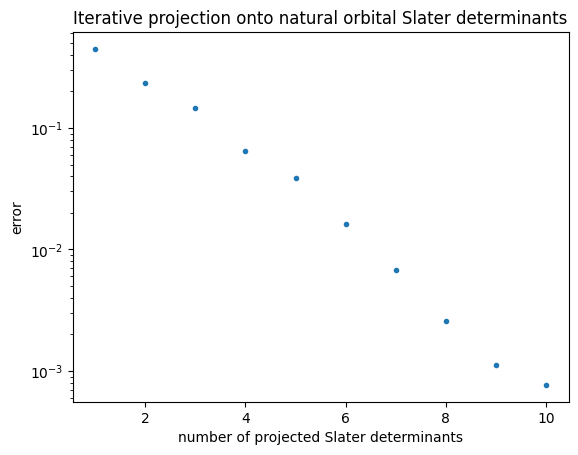

In [12]:
# visualize approximation errors
plt.semilogy(range(1, len(err_list) + 1), err_list, '.')
plt.xlabel("number of projected Slater determinants")
plt.ylabel("error")
plt.title("Iterative projection onto natural orbital Slater determinants")
plt.show()